# 33 — Assign regulatory liquidity horizons

Map every factor to the time needed to exit or hedge it during stress.

LH means Liquidity Horizon. It is different from instrument maturity. A five-year trade can carry a 10-day rate-factor horizon, while its volatility factor can carry 60 days.

This step uses: Risk class, factor type, currency, rating, market capitalisation and commodity type.

It produces: A documented 10, 20, 40, 60 or 120-day horizon for every factor.

> Basel norm applied: MAR33.12 prescribes liquidity-horizon floors by factor category.

$$LH_k\in\{10,20,40,60,120\}\text{ days}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
inventory=stage('01_ima_factor_inventory')
view=inventory[['risk_factor_id','broad_risk_class','liquidity_category','liquidity_horizon_days','factor_type']]
displayed_sample=view.sort_values(['liquidity_horizon_days','broad_risk_class']).head(30)
print(f'Displayed sample: first 30 of {len(view):,} factors after sorting by liquidity horizon and risk class.')
print('The sample does not contain every horizon. The charts below use the complete factor inventory, including 60-day and 120-day factors.')
display(displayed_sample)
example=view[view.risk_factor_id.str.contains('OIS_VOL')].iloc[0]
print(f"{example.risk_factor_id} is interest-rate volatility, so its factor horizon is {example.liquidity_horizon_days} days even though its option tenor is separate.")

Displayed sample: first 30 of 59 factors after sorting by liquidity horizon and risk class.
The sample does not contain every horizon. The charts below use the complete factor inventory, including 60-day and 120-day factors.


,risk_factor_id,broad_risk_class,liquidity_category,liquidity_horizon_days,factor_type
0,APPLE,EQUITY,EQUITY_LARGE_CAP_PRICE,10,standard
22,HDFC_BANK,EQUITY,EQUITY_LARGE_CAP_PRICE,10,standard
26,INFOSYS,EQUITY,EQUITY_LARGE_CAP_PRICE,10,standard
38,NIFTY50,EQUITY,EQUITY_LARGE_CAP_PRICE,10,standard
41,RELIANCE,EQUITY,EQUITY_LARGE_CAP_PRICE,10,standard
8,EURINR,FX,FX_SPECIFIED_PAIR,10,standard
45,USDINR,FX,FX_SPECIFIED_PAIR,10,standard
10,EUR_OIS_1.0Y,INTEREST_RATE,INTEREST_RATE_SPECIFIED_CURRENCY,10,standard
11,EUR_OIS_10.0Y,INTEREST_RATE,INTEREST_RATE_SPECIFIED_CURRENCY,10,standard
12,EUR_OIS_3.0Y,INTEREST_RATE,INTEREST_RATE_SPECIFIED_CURRENCY,10,standard


INR_OIS_VOL_1.0Y_UNDERLYING_5.0Y is interest-rate volatility, so its factor horizon is 60 days even though its option tenor is separate.


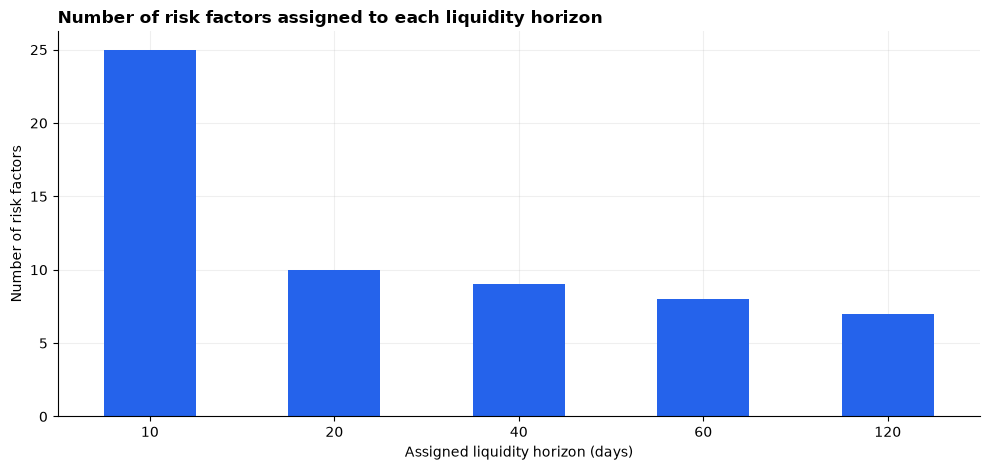

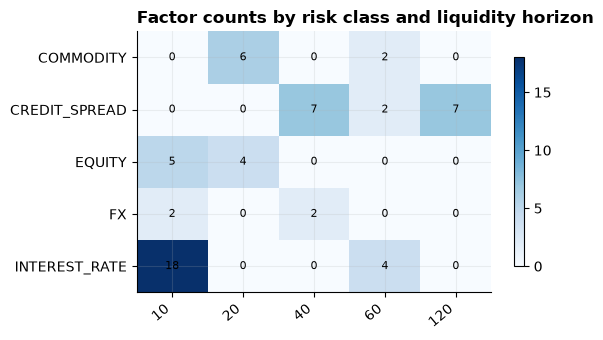

In [3]:
distribution=inventory.liquidity_horizon_days.value_counts().sort_index(); ax=distribution.plot(kind='bar',color='#2563EB'); ax.set_xlabel('Assigned liquidity horizon (days)'); ax.set_ylabel('Number of risk factors'); ax.set_title('Number of risk factors assigned to each liquidity horizon',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()
cross=inventory.groupby(['broad_risk_class','liquidity_horizon_days']).size().unstack(fill_value=0); heatmap(cross,'Factor counts by risk class and liquidity horizon',value_format='.0f')

The bar chart is a distribution of factor assignments: it counts how many factors have been assigned 10, 20, 40, 60 or 120 days. It is not the nested Expected Shortfall calculation. The heatmap uses the same full factor inventory and shows which risk classes create each horizon count. The nesting of these horizon groups is calculated in notebook 35.